# Ch8-2 Playground — 以線性變換的眼光看叉積

> 對應 3Blue1Brown《線性代數的本質》第八章（下）
>
> 上一章我們把 $\vec{v} \times \vec{w}$ 當成計算公式來用：方向用右手定則，長度等於平行四邊形面積，分量用「假行列式」展開。
>
> 這集 3B1B 要回答一個更深的問題：**為什麼那個假行列式公式長這樣？** 答案藏在「對偶性」裡。

## 核心思路（一定要先抓住）

1. 固定 $\vec{v}, \vec{w} \in \mathbb{R}^3$，定義函數
   $$ f(\vec{u}) = \det\bigl([\,\vec{u}\;|\;\vec{v}\;|\;\vec{w}\,]\bigr) $$
   這是「$\vec{u}, \vec{v}, \vec{w}$ 圍成的平行六面體的有號體積」。
2. $f$ 是 $\mathbb{R}^3 \to \mathbb{R}$ 的**線性函數**（行列式對某一 column 是線性的）。
3. **對偶性（Ch7）**：任何 $\mathbb{R}^3 \to \mathbb{R}$ 的線性函數，都對應到一個固定向量 $\vec{p}$，使得 $f(\vec{u}) = \vec{p} \cdot \vec{u}$。
4. 那個 $\vec{p}$ 就是 $\vec{v} \times \vec{w}$。

也就是說，叉積的「定義」其實是：**找到那個唯一的向量 $\vec{p}$，讓 $\vec{p} \cdot \vec{u}$ 等於 $\vec{u}, \vec{v}, \vec{w}$ 的有號體積。**

從這個定義出發，方向（垂直 $\vec{v}, \vec{w}$）、長度（平行四邊形面積）、假行列式公式，全部都會自然掉出來。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

np.set_printoptions(precision=4, suppress=True)
print('✔ Imports ready.')

✔ Imports ready.


---
## Part 1：先複習對偶性（Ch7 的精華）

對偶性說：**任何把 n 維向量壓成一個數字的線性函數**，都可以寫成「跟某個固定向量做點積」。

用矩陣的話講就是：一個 $1 \times n$ 的矩陣 $[p_1, p_2, \ldots, p_n]$ 作用在 $\vec{u}$ 上，等同於向量 $\vec{p} = (p_1, \ldots, p_n)^\top$ 跟 $\vec{u}$ 做點積。

$$ \underbrace{[p_1\;p_2\;p_3]}_{1\times 3 \text{ 矩陣}} \begin{bmatrix} u_1 \\ u_2 \\ u_3 \end{bmatrix} = p_1 u_1 + p_2 u_2 + p_3 u_3 = \vec{p} \cdot \vec{u} $$

這個觀念是這集的關鍵 — 我們等下要把「體積函數」也寫成這個形式。

In [2]:
# === 實驗 1：把線性函數還原成「跟誰點積」===

# 隨便造一個 R^3 -> R 的線性函數
def L(u):
    u = np.asarray(u, dtype=float)
    return 2 * u[0] - 3 * u[1] + 5 * u[2]

# 對偶性說：應該存在 p 使得 L(u) = p · u
# 怎麼找 p？把標準基底丟進去：
p = np.array([L([1, 0, 0]), L([0, 1, 0]), L([0, 0, 1])])
print('還原出的對偶向量 p =', p)

# 隨便試幾個 u 驗證
for u in [[1, 1, 1], [3, -2, 4], [0, 7, -1]]:
    print(f'  L({u}) = {L(u):>6}    p·u = {np.dot(p, u):>6}    一致？{L(u) == np.dot(p, u)}')

還原出的對偶向量 p = [ 2. -3.  5.]
  L([1, 1, 1]) =    4.0    p·u =    4.0    一致？True
  L([3, -2, 4]) =   32.0    p·u =   32.0    一致？True
  L([0, 7, -1]) =  -26.0    p·u =  -26.0    一致？True


---
## Part 2：定義「體積函數」 $f(\vec{u}) = \det([\vec{u}\,|\,\vec{v}\,|\,\vec{w}])$

固定 $\vec{v}, \vec{w}$，讓 $\vec{u}$ 自由變動。把這三個向量當成 $3 \times 3$ 矩陣的三個 column，取 $\det$。

**幾何意義**：這個 $\det$ 等於 $\vec{u}, \vec{v}, \vec{w}$ 圍成的**平行六面體**的有號體積。
- 三向量符合右手定則 → 體積為正
- 三向量符合左手定則 → 體積為負
- 三向量共面 → 體積為 0

我們的目標是：**把 $f(\vec{u})$ 改寫成 $\vec{p} \cdot \vec{u}$ 的形式**。

In [3]:
# === 實驗 2：體積函數 f(u) = det([u | v | w]) ===

v = np.array([1.0, 2.0, 0.0])
w = np.array([0.0, 1.0, 3.0])

def f(u, v=v, w=w):
    """u, v, w 圍成的平行六面體有號體積。"""
    M = np.column_stack([u, v, w])
    return np.linalg.det(M)

# 試幾組 u
for u in [[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 2, 0], [2, 4, 6]]:
    print(f'f({u}) = {f(u):+.4f}')

print('\n注意：f([1,2,0]) = 0，因為 [1,2,0] 跟 v 同方向 → 三向量共面 → 體積 0。')
print('     f([2,4,6]) = 0，因為 [2,4,6] = 2v + 2w → 三向量共面。')

f([1, 0, 0]) = +6.0000
f([0, 1, 0]) = -3.0000
f([0, 0, 1]) = +1.0000
f([1, 2, 0]) = +0.0000
f([2, 4, 6]) = +6.0000

注意：f([1,2,0]) = 0，因為 [1,2,0] 跟 v 同方向 → 三向量共面 → 體積 0。
     f([2,4,6]) = 0，因為 [2,4,6] = 2v + 2w → 三向量共面。


---
## Part 3：$f$ 是線性的

為什麼能套對偶性？因為 $f$ 是 $\mathbb{R}^3 \to \mathbb{R}$ 的線性函數。要驗證兩條：

1. **可加性**：$f(\vec{u}_1 + \vec{u}_2) = f(\vec{u}_1) + f(\vec{u}_2)$
2. **齊次性**：$f(c\,\vec{u}) = c\, f(\vec{u})$

幾何直覺：把 $\vec{u}$ 拉長兩倍，平行六面體一個方向也拉長兩倍 → 體積也兩倍。把 $\vec{u}$ 拆成兩個向量相加，體積也會對應拆開。這是行列式「對某一 column 是多重線性」的具體表現。

In [4]:
# === 實驗 3：數值驗證 f 的線性 ===

rng = np.random.default_rng(0)
u1 = rng.normal(size=3)
u2 = rng.normal(size=3)
c = 3.7

lhs_add = f(u1 + u2)
rhs_add = f(u1) + f(u2)
print(f'可加性: f(u1+u2) = {lhs_add:+.6f}    f(u1)+f(u2) = {rhs_add:+.6f}    ✔' if np.isclose(lhs_add, rhs_add) else '✘')

lhs_hom = f(c * u1)
rhs_hom = c * f(u1)
print(f'齊次性: f(c·u) = {lhs_hom:+.6f}    c·f(u) = {rhs_hom:+.6f}    ✔' if np.isclose(lhs_hom, rhs_hom) else '✘')

可加性: f(u1+u2) = +4.389122    f(u1)+f(u2) = +4.389122    ✔
齊次性: f(c·u) = +6.627139    c·f(u) = +6.627139    ✔


---
## Part 4：對偶性出馬 — 找出那個 $\vec{p}$

既然 $f$ 線性，對偶性保證**存在唯一**的 $\vec{p}$ 使得 $f(\vec{u}) = \vec{p} \cdot \vec{u}$。怎麼找？  
**把標準基底 $\hat{i}, \hat{j}, \hat{k}$ 丟進去**：

$$ p_1 = f(\hat{i}) = \det\!\begin{bmatrix}1 & v_1 & w_1\\ 0 & v_2 & w_2\\ 0 & v_3 & w_3\end{bmatrix} = v_2 w_3 - v_3 w_2 $$

$$ p_2 = f(\hat{j}) = \det\!\begin{bmatrix}0 & v_1 & w_1\\ 1 & v_2 & w_2\\ 0 & v_3 & w_3\end{bmatrix} = v_3 w_1 - v_1 w_3 $$

$$ p_3 = f(\hat{k}) = \det\!\begin{bmatrix}0 & v_1 & w_1\\ 0 & v_2 & w_2\\ 1 & v_3 & w_3\end{bmatrix} = v_1 w_2 - v_2 w_1 $$

這三個分量**正是叉積 $\vec{v} \times \vec{w}$ 的三個分量！**

所以叉積的「真正定義」可以寫成：

$$ \boxed{(\vec{v} \times \vec{w}) \cdot \vec{u} \;=\; \det\bigl([\,\vec{u}\;|\;\vec{v}\;|\;\vec{w}\,]\bigr)} $$

In [5]:
# === 實驗 4：用對偶性把 p 還原出來，看是否等於 v × w ===

p_recovered = np.array([
    f([1, 0, 0]),
    f([0, 1, 0]),
    f([0, 0, 1]),
])
vxw = np.cross(v, w)

print('用對偶性還原的 p =', p_recovered)
print('np.cross(v, w)   =', vxw)
print('一致？', np.allclose(p_recovered, vxw))

# 用一些隨機 u 驗證 (v×w)·u == det([u|v|w])
print('\n— 驗證 (v×w)·u = det([u|v|w]) —')
for _ in range(4):
    u = rng.normal(size=3)
    lhs = np.dot(vxw, u)
    rhs = f(u)
    print(f'  u = {u}    (v×w)·u = {lhs:+.4f}    det = {rhs:+.4f}    {"✔" if np.isclose(lhs, rhs) else "✘"}')

用對偶性還原的 p = [ 6. -3.  1.]
np.cross(v, w)   = [ 6. -3.  1.]
一致？ True

— 驗證 (v×w)·u = det([u|v|w]) —
  u = [ 1.304   0.9471 -0.7037]    (v×w)·u = +4.2790    det = +4.2790    ✔
  u = [-1.2654 -0.6233  0.0413]    (v×w)·u = -5.6814    det = -5.6814    ✔
  u = [-2.325  -0.2188 -1.2459]    (v×w)·u = -14.5397    det = -14.5397    ✔
  u = [-0.7323 -0.5443 -0.3163]    (v×w)·u = -3.0771    det = -3.0771    ✔


---
## Part 5：從這個定義「為什麼方向垂直」「為什麼長度等於面積」自然掉出來

我們現在有 $(\vec{v} \times \vec{w}) \cdot \vec{u} = $「$\vec{u}, \vec{v}, \vec{w}$ 圍成的平行六面體體積」。

**體積還能怎麼算？** 用「底面積 × 高」的公式：

$$ \text{體積} = \underbrace{\|\vec{v} \times \vec{w}\|}_{\text{底（平行四邊形）面積？}} \times \underbrace{(\text{$\vec{u}$ 投影到「垂直 $\vec{v}, \vec{w}$」方向的長度})}_{\text{高}} $$

把右邊改寫一下：

$$ \text{體積} = \bigl(\text{底面積}\bigr) \times \bigl(\hat{n} \cdot \vec{u}\bigr) = \bigl(\text{底面積} \cdot \hat{n}\bigr) \cdot \vec{u} $$

其中 $\hat{n}$ 是垂直於 $\vec{v}, \vec{w}$ 平面的單位向量（方向由右手定則決定，這樣體積符號才一致）。

**比較兩邊**：
$$ (\vec{v} \times \vec{w}) \cdot \vec{u} = \bigl(\text{底面積} \cdot \hat{n}\bigr) \cdot \vec{u} \quad \forall \vec{u} $$

因此：
$$ \boxed{\vec{v} \times \vec{w} = (\text{平行四邊形面積}) \cdot \hat{n}} $$

**這就同時解釋了 Ch8-1 死記的兩件事**：
- **方向**：$\vec{v} \times \vec{w} \perp \vec{v}$ 且 $\perp \vec{w}$（因為它正比於 $\hat{n}$）
- **長度**：$\|\vec{v} \times \vec{w}\| = $ 平行四邊形面積

In [6]:
# === 實驗 5：數值驗證「方向垂直」「長度=面積」「體積=底×高」===

v = np.array([1.0, 2.0, 0.0])
w = np.array([0.0, 1.0, 3.0])
u = np.array([2.0, 0.5, 1.0])

vxw = np.cross(v, w)

# (1) 方向：v×w 與 v、w 都正交
print('— 方向 —')
print(f'(v×w)·v = {np.dot(vxw, v):+.6f}    (期望 0)')
print(f'(v×w)·w = {np.dot(vxw, w):+.6f}    (期望 0)')

# (2) 長度 = 平行四邊形面積
# 平行四邊形面積也可以用 |v||w|sin(θ) 算，或 sqrt(|v|²|w|² − (v·w)²)
area_from_cross = np.linalg.norm(vxw)
area_from_formula = np.sqrt(np.dot(v, v) * np.dot(w, w) - np.dot(v, w) ** 2)
print('\n— 長度 = 面積 —')
print(f'‖v×w‖             = {area_from_cross:.6f}')
print(f'√(|v|²|w|²−(v·w)²) = {area_from_formula:.6f}')

# (3) 體積 = 底面積 × 高（u 在 n̂ 方向上的投影）
n_hat = vxw / np.linalg.norm(vxw)
height = np.dot(n_hat, u)
vol_base_times_height = area_from_cross * height
vol_det = np.linalg.det(np.column_stack([u, v, w]))
vol_dot = np.dot(vxw, u)
print('\n— 體積三種算法都應該一致 —')
print(f'底面積 × 高             = {vol_base_times_height:+.6f}')
print(f'(v×w)·u                 = {vol_dot:+.6f}')
print(f'det([u|v|w])            = {vol_det:+.6f}')

— 方向 —
(v×w)·v = +0.000000    (期望 0)
(v×w)·w = +0.000000    (期望 0)

— 長度 = 面積 —
‖v×w‖             = 6.782330
√(|v|²|w|²−(v·w)²) = 6.782330

— 體積三種算法都應該一致 —
底面積 × 高             = +11.500000
(v×w)·u                 = +11.500000
det([u|v|w])            = +11.500000


---
## Part 6：「假行列式」公式的真正來源

Ch8-1 教過用「符號版行列式」算叉積：

$$ \vec{v} \times \vec{w} = \det\!\begin{bmatrix} \hat{i} & v_1 & w_1 \\ \hat{j} & v_2 & w_2 \\ \hat{k} & v_3 & w_3 \end{bmatrix} $$

這個寫法很怪 — 第一 column 是向量、其他是純量，根本不是標準行列式。為什麼合法？

**這集解釋了**：那個式子根本不是「真的算行列式」，而是把第 4 部分的求 $\vec{p}$ 的過程**打包成記憶口訣**：

- 把 $\hat{i}$ 放到第一 column 第一個位置 → cofactor 展開取出 $v_2 w_3 - v_3 w_2$ → 那就是 $p_1$
- 把 $\hat{j}$ 放到第一 column 第二個位置 → cofactor 展開取出 $v_3 w_1 - v_1 w_3$ → 那就是 $p_2$
- 把 $\hat{k}$ 放到第一 column 第三個位置 → cofactor 展開取出 $v_1 w_2 - v_2 w_1$ → 那就是 $p_3$

每個 $\hat{e}_k$ 「假裝代入第一 column」，就等同於 $f(\hat{e}_k)$，也就是對偶向量 $\vec{p}$ 的第 k 個分量。**結果加起來就是 $\vec{p} = \vec{v} \times \vec{w}$**。

假行列式不是魔法，是對偶性的速記法。

In [7]:
# === 實驗 6：用 cofactor 展開親手算叉積，三條路線結果一致 ===

v = np.array([1.0, 2.0, 3.0])
w = np.array([4.0, 5.0, 6.0])

# 路線 A — Ch8-1 的「假行列式」cofactor 展開
p1_A = v[1] * w[2] - v[2] * w[1]
p2_A = v[2] * w[0] - v[0] * w[2]
p3_A = v[0] * w[1] - v[1] * w[0]
p_A = np.array([p1_A, p2_A, p3_A])

# 路線 B — Ch8-2 的對偶性：把 ê_k 丟進 f(u) = det([u|v|w])
def f(u, v=v, w=w):
    return np.linalg.det(np.column_stack([u, v, w]))
p_B = np.array([f([1, 0, 0]), f([0, 1, 0]), f([0, 0, 1])])

# 路線 C — NumPy 內建
p_C = np.cross(v, w)

print('A. 假行列式 cofactor 展開:', p_A)
print('B. 對偶性 f(ê_k):         ', p_B)
print('C. np.cross(v, w):        ', p_C)
print('\n三條路線一致？', np.allclose(p_A, p_B) and np.allclose(p_B, p_C))

A. 假行列式 cofactor 展開: [-3.  6. -3.]
B. 對偶性 f(ê_k):          [-3.  6. -3.]
C. np.cross(v, w):         [-3.  6. -3.]

三條路線一致？ True


---
## Part 7：視覺化 — 平行六面體 + 叉積向量

把 $\vec{u}, \vec{v}, \vec{w}$ 圍成的平行六面體畫出來；同時畫出 $\vec{v} \times \vec{w}$，看它怎麼垂直於 $\vec{v}, \vec{w}$ 形成的底面。

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_45630/4253337620.py:51: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_45630/4253337620.py:51: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_45630/4253337620.py:51: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_45630/4253337620.py:51: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_45630/4253337620.py:51: UserWarning: Glyph 39636 (\N{CJK UNIFIED IDEOGRAPH-9AD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd

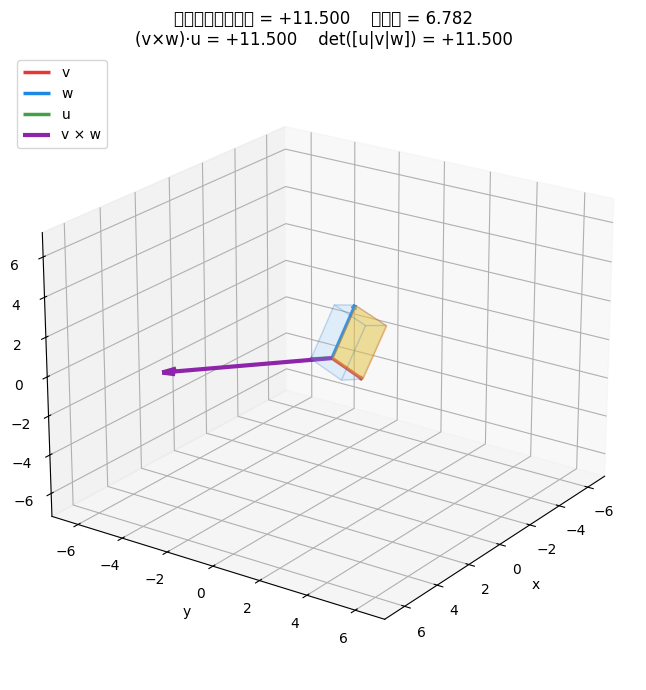

In [8]:
# === 實驗 7：畫平行六面體 + v×w ===

def plot_parallelepiped(u, v, w, elev=22, azim=35):
    u, v, w = map(np.asarray, (u, v, w))
    vxw = np.cross(v, w)
    vol = np.linalg.det(np.column_stack([u, v, w]))
    area = np.linalg.norm(vxw)

    O = np.zeros(3)
    pts = {
        'O': O, 'u': u, 'v': v, 'w': w,
        'u+v': u + v, 'u+w': u + w, 'v+w': v + w,
        'u+v+w': u + v + w,
    }
    faces = [
        [pts['O'],     pts['v'],     pts['v+w'],   pts['w']],     # 底（v, w 圍成）
        [pts['u'],     pts['u+v'],   pts['u+v+w'], pts['u+w']],   # 頂
        [pts['O'],     pts['u'],     pts['u+v'],   pts['v']],
        [pts['O'],     pts['u'],     pts['u+w'],   pts['w']],
        [pts['v'],     pts['u+v'],   pts['u+v+w'], pts['v+w']],
        [pts['w'],     pts['u+w'],   pts['u+v+w'], pts['v+w']],
    ]

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=elev, azim=azim)

    # 底面 (v, w)：強調為平行四邊形
    base = Poly3DCollection([faces[0]], alpha=0.45, facecolor='#FFC107', edgecolor='#FF6F00')
    ax.add_collection3d(base)

    # 其他面
    others = Poly3DCollection(faces[1:], alpha=0.12, facecolor='#90CAF9', edgecolor='#1565C0')
    ax.add_collection3d(others)

    # 三個基底向量
    ax.quiver(*O, *v, color='#E53935', arrow_length_ratio=0.08, lw=2.5, label='v')
    ax.quiver(*O, *w, color='#1E88E5', arrow_length_ratio=0.08, lw=2.5, label='w')
    ax.quiver(*O, *u, color='#43A047', arrow_length_ratio=0.08, lw=2.5, label='u')
    # v × w
    ax.quiver(*O, *vxw, color='#8E24AA', arrow_length_ratio=0.08, lw=3, label='v × w')

    lim = max(np.abs(np.concatenate([u, v, w, vxw]))) * 1.2
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_title(
        f'平行六面體：體積 = {vol:+.3f}    底面積 = {area:.3f}\n'
        f'(v×w)·u = {np.dot(vxw, u):+.3f}    det([u|v|w]) = {vol:+.3f}'
    )
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

plot_parallelepiped(u=[2, 0.5, 1], v=[1, 2, 0], w=[0, 1, 3])

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_45630/4253337620.py:51: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_45630/4253337620.py:51: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_45630/4253337620.py:51: UserWarning: Glyph 20845 (\N{CJK UNIFIED IDEOGRAPH-516D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_45630/4253337620.py:51: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_45630/4253337620.py:51: UserWarning: Glyph 39636 (\N{CJK UNIFIED IDEOGRAPH-9AD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/w8/8vzd

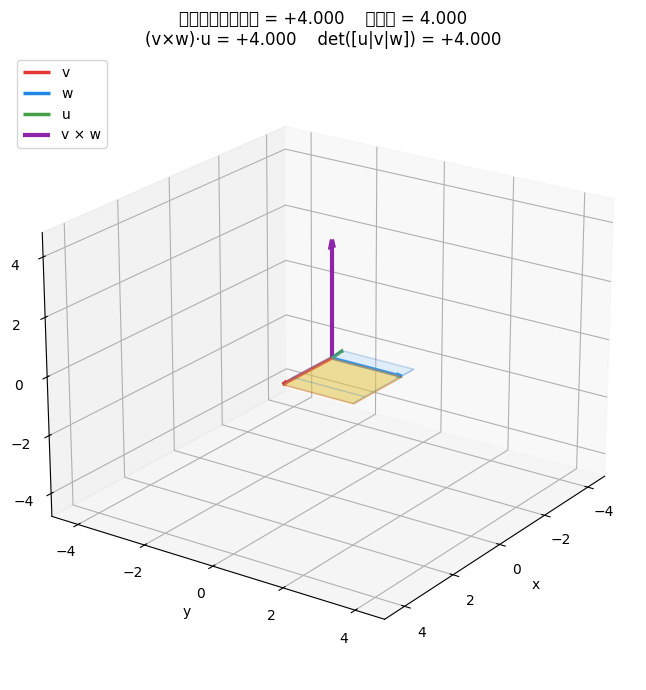

In [9]:
# === 練習區：自由換 u, v, w，觀察體積和 v×w 的關係 ===

my_u = [1, 1, 1]    # ← 改這裡
my_v = [2, 0, 0]    # ← 改這裡
my_w = [0, 2, 0]    # ← 改這裡

# 想想看：如果 u 落在 v、w 形成的平面裡，會發生什麼？
plot_parallelepiped(my_u, my_v, my_w)

---
## 總結

| 概念 | Ch8-1 教法 | Ch8-2 真正定義 |
|---|---|---|
| 叉積本質 | 用公式硬算 | $(\vec{v}\times\vec{w})\cdot\vec{u} = \det([\vec{u}\,\vec{v}\,\vec{w}])$ 對所有 $\vec{u}$ 都成立 |
| 方向垂直 | 死記右手定則 | 因為 $\vec{v}\times\vec{w}$ 正比於 $\hat{n}$（底面法向量） |
| 長度=面積 | 死記公式 | 體積 = 底面積 × 高 → 自然掉出來 |
| 假行列式 | 「就是這樣記」 | 對偶性求 $\vec{p} = (f(\hat{i}), f(\hat{j}), f(\hat{k}))$ 的速記 |

### 一句話記住

> **叉積就是對偶性下的「體積函數」**：找一個向量 $\vec{p}$，讓「跟 $\vec{p}$ 點積」等於「跟 $\vec{v}, \vec{w}$ 圍成的平行六面體有號體積」。

### 為什麼在深度學習裡這個觀點重要？

本身叉積在 DL 並不常見（DL 多在高維空間，叉積只在 3D 定義）。但**對偶性**這個觀點是 DL 的核心：

- 神經網路的 logits 層 $\mathbf{w}^\top \mathbf{x} + b$ 就是個線性函數 $\mathbb{R}^n \to \mathbb{R}$。
- 「線性函數 ↔ 一個向量」這件事，讓我們可以把 attention、kernel、similarity score 等都統一成「跟某個向量做內積」的視角。
- 這集真正要傳遞的是：**面對一個複雜的多元函數，先問「它線性嗎？」如果線性，就有一個對偶向量在背後等你**。